# Tema IV — Análisis Exploratorio de Datos (EDA)

## Objetivos de Aprendizaje

Al finalizar este cuaderno serás capaz de:

- Comprender Conceptualmente el propósito del EDA.
- Evaluar la integridad de los datos.
- Realizar Análisis Univariantes.
- Detectar y Gestionar Anomalias.
- Realizar Análisis Bivariantes.
- Realizar Análisis Multivariantes.
- Sintetizar hallazgos, comunicar datos (Data Storytelling) y arribar a conclusiones.
___


## Marco Conceptual del EDA y Diagnóstico Inicial (Data Profiling)

### Objetivos

Al finalizar este apartado serás capaz de:

* Comprender la finalidad del Análisis Exploratorio de Datos (EDA) en el ciclo de vida del análisis de datos.
* Distinguir entre variables cualitativas y cuantitativas y aplicar el tratamiento adecuado a cada una.
* Realizar un diagnóstico inicial de la salud de los datos (Data Health Check).
* Configurar el entorno gráfico integrando Seaborn, Matplotlib y Pandas.

### Introducción

El **Análisis Exploratorio de Datos (EDA)** es una metodología analítica que prioriza el examen visual y estadístico previo de un conjunto de datos antes de aplicar cualquier modelo predictivo, prueba de hipótesis formal o algoritmo de Machine Learning.

Acuñado por el matemático John Tukey en 1977, persigue responder a cuatro preguntas fundamentales:

1. ¿Qué estructura tienen los datos? (Dimensiones, tipos de variables, formatos).
2. ¿Qué tan limpios están? (Valores faltantes, incoherencias, duplicados).
3. ¿Cómo se distribuyen las variables? (Centros, dispersión, formas, sesgos).
4. ¿Existen patrones, anomalías o relaciones evidentes? (Outliers, correlaciones, agrupamientos).

### Tipología de Variables en EDA

El primer paso de un análisis consiste en clasificar correctamente el tipo de cada variable, ya que esto determina qué gráficos y métricas estadísticas son válidos.

|Tipo de Variable|Subtipo|Descripción|Ejemplos|Métricas y Gráficos válidos|
|----------------|-------|-----------|--------|---------------------------|
|Cualitativa (Categórica)|Nominal|Categorías sin orden intrínseco.|Estado civil, Ciudad, Sector|Frecuencias, Moda.countplot, gráfico de barras.|
|Cualitativa (Categórica)|Ordinal|Categorías con una jerarquía u orden lógico.|Nivel educativo, Satisfacción (1-5)|Frecuencias, Moda, Mediana.Barplot ordenado.|
|Cuantitativa (Numérica)|Discreta|Valores numéricos enteros (conteo).|Número de hijos, Ventas realizadas|Media, Mediana, Rango, IQR.Histograma, countplot.|
|Cuantitativa (Numérica)|Continua|Valores reales (mediciones en escala continua).|Precio, Temperatura, Retorno bursátil|Media, Mediana, Desviación típica, Asimetría.Histograma, KDE, boxplot.|

### Configuración del Entorno Gráfico (Seaborn + Matplotlib)

En el ecosistema de Python, Matplotlib actúa como el motor gráfico de bajo nivel (control total del lienzo, ejes, títulos), mientras que Seaborn se apoya sobre él para ofrecer una interfaz de alto nivel orientada al análisis estadístico directamente integrada con DataFrames de Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración global del estilo gráfico para un aspecto profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 10

### Diagnóstico Inicial de Salud (Data Profiling)

Antes de generar gráficos, se debe auditar la integridad del dataset con una batería de inspecciones rápidas:


In [2]:
def perfilado_inicial(df):
    """Genera un reporte rápido sobre la salud del DataFrame."""
    reporte = pd.DataFrame({
        "Tipo_Dato": df.dtypes,
        "Valores_Nulos": df.isna().sum(),
        "%_Nulos": (df.isna().sum() / len(df) * 100).round(2),
        "Valores_Unicos": df.nunique(),
        "Cardinalidad_%": (df.nunique() / len(df) * 100).round(2)
    })
    return reporte

# Ejemplo de uso con un dataset de prueba
df_ejemplo = pd.DataFrame({
    "ID": [101, 102, 103, 104, 105],
    "Categoria": ["A", "B", "A", "C", None],
    "Precio": [25.5, 40.0, np.nan, 15.2, 33.0]
})

print(perfilado_inicial(df_ejemplo))

          Tipo_Dato  Valores_Nulos  %_Nulos  Valores_Unicos  Cardinalidad_%
ID            int64              0      0.0               5           100.0
Categoria       str              1     20.0               3            60.0
Precio      float64              1     20.0               4            80.0


### Métricas de diagnóstico clave a observar:

* Completitud (%_Nulos): Identificar variables con un porcentaje de ausentes crítico ($>20\%-50\%$).
* Cardinalidad (Valores_Unicos):
    - Una variable de texto con cardinalidad cercana al $100\%$ suele ser un identificador único (ID, hash) sin valor predictivo.
    - Una variable numérica con muy poca cardinalidad (ej. 2 o 3 valores) actúa en la práctica como una variable categórica.

### Ideas clave

- Entender antes de modelar: El EDA no es un trámite formal; previene cometer errores analíticos graves al detectar inconsistencias de datos de forma temprana.
- Formato adecuado de variables: Si una variable categórica se carga como número (ej. Código Postal como entero), se debe castear a object o category para no distorsionar las métricas cuantitativas.
- Sinergia gráfica: Matplotlib da la flexibilidad de maquetación (plt.figure(), plt.title()), mientras que Seaborn realiza la agregación estadística automática sobre los DataFrames.
- Análisis de cardinalidad: Ayuda a descartar variables irrelevantes (identificadores únicos) y a reclasificar variables codificadas de forma numérica.
___

## Análisis Univariante (Estudio de una Sola Variable)

### Objetivos

Al finalizar este apartado serás capaz de:

* Analizar la distribución de variables cuantitativas continuas y discretas mediante métricas de posición, dispersión y forma.
* Visualizar la forma de la distribución utilizando histogramas, curvas de densidad (KDE) y gráficos de caja (Boxplots).
* Analizar variables cualitativas (categóricas) a través de tablas de frecuencia y gráficos de barras.

### Variables Cuantitativas: Métricas Estadísticas

El análisis de una variable numérica busca responder tres preguntas: ¿dónde está el centro de los datos?, ¿qué tan dispersos están? y ¿es la distribución simétrica?

In [3]:
# Variable numérica de prueba (ej. Salarios)
datos = pd.Series([22000, 25000, 25000, 28000, 31000, 35000, 42000, 95000])

# 1. Tendencia central
media = datos.mean()
mediana = datos.median()
moda = datos.mode()[0]

# 2. Dispersión
desviacion = datos.std()
iqr = datos.quantile(0.75) - datos.quantile(0.25) # Rango Intercuartílico

# 3. Forma
asimetria = datos.skew()  # Skewness (>0 indica sesgo a la derecha)
curtosis = datos.kurt()   # Kurtosis (>0 indica colas pesadas)

**Interpretación de la Forma de la Distribución:**

- Sesgo a la derecha (Asimetría positiva, skew > 0): La media es significativamente mayor que la mediana debido a valores extremadamente altos (ej. salarios, precios de vivienda).
- Distribución Simétrica (skew ≈ 0): La media y la mediana coinciden en el centro (ej. altura, errores de medición).

### Variables Cuantitativas: Visualización Exploratoria

Para inspeccionar la forma de una variable continua se combinan tres representaciones gráficas esenciales:

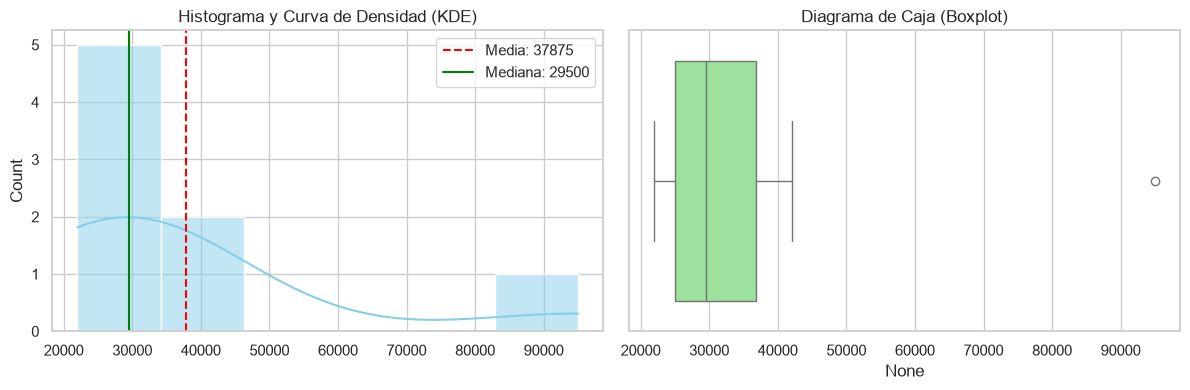

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A. Histograma + KDE (Densidad Kernel)
sns.histplot(datos, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Histograma y Curva de Densidad (KDE)")
axes[0].axvline(datos.mean(), color="red", linestyle="--", label=f"Media: {datos.mean():.0f}")
axes[0].axvline(datos.median(), color="green", linestyle="-", label=f"Mediana: {datos.median():.0f}")
axes[0].legend()

# B. Gráfico de Caja (Boxplot)
sns.boxplot(x=datos, ax=axes[1], color="lightgreen")
axes[1].set_title("Diagrama de Caja (Boxplot)")

plt.tight_layout()
plt.show()

### Variables Categóricas: Frecuencias y Representación

En variables cualitativas, el objetivo es medir el peso relativo de cada categoría mediante frecuencias absolutas y porcentuales.

C:\Users\jorge.crespo.UNEATPDIPAS\AppData\Local\Temp\ipykernel_11716\831907250.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=ciudades, order=frec_absoluta.index, palette="viridis") # Este código genera un warning futuro. Si no se corrige, el código dejará de funcionar cuando Seaborn se actualice a la version v0.14.0


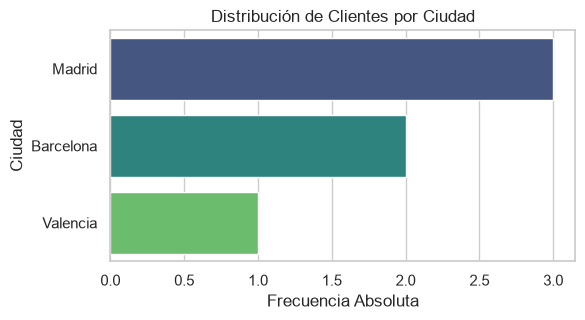

In [12]:
# Variable categórica de prueba
ciudades = pd.Series(["Madrid", "Barcelona", "Madrid", "Valencia", "Madrid", "Barcelona"])

# Tablas de Frecuencias
frec_absoluta = ciudades.value_counts()
frec_relativa = ciudades.value_counts(normalize=True) * 100

# Representación Gráfica con Seaborn
plt.figure(figsize=(6, 3))
sns.countplot(y=ciudades, order=frec_absoluta.index, palette="viridis") # Este código genera un warning futuro. Si no se corrige, el código dejará de funcionar cuando Seaborn se actualice a la version v0.14.0
# sns.countplot(y=ciudades, order=frec_absoluta.index, hue=ciudades, palette="viridis", legend=False)
plt.title("Distribución de Clientes por Ciudad")
plt.xlabel("Frecuencia Absoluta")
plt.ylabel("Ciudad")
plt.show()

### Ideas clave

- Media vs. Mediana: Si la distribución presenta un sesgo acentuado (skew > 1), la mediana es una medida de tendencia central mucho más representativa que la media.
- Complementariedad visual: El histograma permite observar la bimodalidad (múltiples picos) de una variable, mientras que el boxplot es la herramienta idónea para identificar cuantitativamente la ubicación de los cuartiles y outliers.
- Orden en categóricas: Al graficar variables cualitativas, ordena siempre las barras de mayor a menor frecuencia (order=df['col'].value_counts().index) para facilitar la lectura del gráfico.
- Uso crítico de gráficos de sectores: Evita los gráficos de tarta (pie charts); los gráficos de barras horizontales facilitan la comparación precisa entre categorías con frecuencias parecidas.
___

## Detección y Gestión de Anomalías (Outliers)

### Objetivos

Al finalizar este apartado serás capaz de: 

* Comprender qué es un outlier (valor atípico) y diferenciar entre errores de medición y valores extremos reales.
* Identificar outliers cuantitativamente utilizando el Rango Intercuartílico (IQR) y el Z-Score.
* Aplicar estrategias avanzadas de tratamiento (Trimming, Winsorizing, Transformaciones).

### Introducción

Un outlier o valor atípico es una observación que se aleja significativamente del patrón general del resto de los datos.

- **Causas comunes:** Errores de entrada de datos (ej. un salario de 9999999), errores de medición en instrumentos, o eventos excepcionales legítimos (ej. un pico de tráfico en un servidor web durante un ciberataque).

- **Impacto:** Distorsiona severamente las métricas basadas en la media y la desviación estándar, altera las matrices de correlación y puede arruinar el entrenamiento de algoritmos sensibles a la distancia.

### Métodos de Detección

Existen dos enfoques matemáticos estándar para aislar valores extremos en datos unidimensionales:

In [13]:
# Serie de datos con outliers
precios = pd.Series([100, 105, 110, 108, 112, 115, 109, 107, 500, 12, 111])

# -------------------------------------------------------------
# Método 1: Rango Intercuartílico (IQR) - Robusto y no paramétrico
# -------------------------------------------------------------
Q1 = precios.quantile(0.25)
Q3 = precios.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = precios[(precios < limite_inferior) | (precios > limite_superior)]
print(f"Limites IQR: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print("Outliers (IQR):\n", outliers_iqr)

# -------------------------------------------------------------
# Método 2: Z-Score (Requiere distribución aproximadamente normal)
# -------------------------------------------------------------
z_scores = (precios - precios.mean()) / precios.std()
outliers_zscore = precios[np.abs(z_scores) > 3]  # Umbral habitual |Z| > 3

Limites IQR: [97.75, 119.75]
Outliers (IQR):
 8    500
9     12
dtype: int64


### Estrategias de Tratamiento de Outliers

No todos los outliers deben eliminarse automáticamente. La estrategia a elegir depende del origen del dato:

|Estrategia|Descripción|Uso recomendado|Código en Pandas|
|----------|-----------|---------------|----------------|
|Conservación|Mantener los datos intactos.|Eventos reales raros pero importantes para el negocio (ej. fraudes).|Ningún cambio|
|Eliminación (Trimming)|Filtrar y descartar los registros atípicos.|Errores de medición irreproducibles o irrecuperables.|df[df['val'] <= limite_sup]|
|Acotado (Winsorizing)|Reemplazar los valores atípicos por el límite superior/inferior.|Conservar el tamaño muestral evitando que el dato distorsione.|df['val'].clip(lower, upper)|
|Transformación|Aplicar escala logarítmica para comprimir la cola superior.|Variables numéricas con sesgo extremo a la derecha.|np.log1p(df['val'])|

In [14]:
# Ejemplo de Acotado (Winsorizing / Clipping) con Pandas
precios_acotados = precios.clip(lower=limite_inferior, upper=limite_superior)
print("Original máximo:", precios.max())          # 500
print("Acotado máximo:", precios_acotados.max())  # 122.5 (Límite superior)

Original máximo: 500
Acotado máximo: 119.75


### Ideas clave

- IQR es más seguro que Z-Score: El método IQR no asume que los datos siguen una distribución Normal/Gaussiana, lo que lo hace idóneo para la mayoría de los datasets reales.
- Evitar la eliminación a ciegas: Borrar outliers legítimos elimina información valiosa sobre la variabilidad real del fenómeno estudiando.
- Transformación logarítmica: Aplicar np.log1p() a variables monetarias o de conteo masivo suele "normalizar" la distribución y atenuar el efecto visual y estadístico de las colas pesadas.
___

## Análisis Bivariante (Relación entre Dos Variables)

### Objetivos

Al finalizar este apartado serás capaz de:

* Evaluar la relación entre dos variables cuantitativas mediante gráficos de dispersión y coeficientes de correlación.
* Analizar la relación entre una variable cuantitativa y una categórica mediante agregaciones por grupo y gráficos distribucionales comparativos.
* Cruzar dos variables categóricas mediante tablas de contingencia y gráficos de barras agrupados/apilados.

### Relación de Variables - Cuantitativa vs. Cuantitativa: Scatter Plots y Correlación

Evalúa si los cambios en una variable continua se asocian con cambios en otra.

- **Coeficiente de Pearson ($r$):** Mide relaciones estrictamente lineales entre variables con distribución Normal.
- **Coeficiente de Spearman ($\rho$):** Mide relaciones monótonas (crecientes/decrecientes no necesariamente lineales) y es robusto frente a outliers o distribuciones no normales.

In [ ]:
# Dataset de prueba
df = pd.DataFrame({
    "Experiencia": [1, 2, 3, 5, 7, 8, 10, 12],
    "Salario": [22000, 25000, 27000, 35000, 48000, 52000, 65000, 78000]
})

# 1. Cálculo de Correlación
correlacion_pearson = df["Experiencia"].corr(df["Salario"], method="pearson")
print(f"Correlación de Pearson: {correlacion_pearson:.2f}")

# 2. Gráfico de Dispersión con Línea de Tendencia
plt.figure(figsize=(7, 4))
sns.regplot(data=df, x="Experiencia", y="Salario", scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.title("Relación entre Años de Experiencia y Salario")
plt.show()

### Relación de Variables - Cuantitativa vs. Categórica: Comparación de Grupos

Evalúa cómo varía una métrica continua entre los diferentes niveles de una variable cualitativa.

In [ ]:
# Dataset de prueba
df_empleados = pd.DataFrame({
    "Departamento": ["IT", "IT", "Ventas", "Ventas", "HR", "HR", "IT", "Ventas"],
    "Salario": [45000, 50000, 32000, 28000, 30000, 33000, 60000, 35000]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A. Boxplot Comparativo
sns.boxplot(data=df_empleados, x="Departamento", y="Salario", ax=axes[0], palette="Set2")
axes[0].set_title("Distribución del Salario por Departamento (Boxplot)")

# B. Violin Plot (Muestra además la densidad/forma de los datos en cada grupo)
sns.violinplot(data=df_empleados, x="Departamento", y="Salario", ax=axes[1], palette="Set2", inner="quartile")
axes[1].set_title("Densidad del Salario por Departamento (Violin Plot)")

plt.tight_layout()
plt.show()

### Relación de Variables - Categórica vs. Categórica: Tablas de Contingencia y Gráficos Apilados

Examina la frecuencia conjunta y la asociación entre dos variables cualitativas.

In [ ]:
# Dataset de prueba
df_clientes = pd.DataFrame({
    "Segmento": ["VIP", "VIP", "Estándar", "Estándar", "Estándar", "VIP", "VIP"],
    "Compró": ["Sí", "Sí", "No", "Sí", "No", "Sí", "No"]
})

# 1. Tabla de Contingencia (Frecuencias Relativas Porcentuales por Fila)
tabla_cruzada = pd.crosstab(df_clientes["Segmento"], df_clientes["Compró"], normalize="index") * 100
print(tabla_cruzada)

# 2. Gráfico de Barras Apilado (100% Stacked Bar Chart)
tabla_cruzada.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="viridis")
plt.title("Proporción de Compra por Segmento de Cliente")
plt.ylabel("Porcentaje (%)")
plt.legend(title="Compró", bbox_to_anchor=(1.05, 1))
plt.show()

### Ideas clave

- Correlación no implica causalidad: Que dos variables numéricas tengan un $r \approx 1$ indica asociación matemática, pero no que una cause la otra (posible sesgo por variables de confusión).
- Spearman antes que Pearson si hay dudas: Ante la presencia de outliers o distribuciones asimétricas, el coeficiente de Spearman refleja de forma más realista la dependencia entre variables.
- Violinplot vs Boxplot: El gráfico de violín aporta la ventaja de visibilizar bimodalidades (dos picos) dentro de un grupo que el boxplot estándar oculta.
- Normalización en tablas cruzadas: Utiliza normalize='index' o normalize='columns' en pd.crosstab() para comparar proporciones relativas reales en lugar de recuentos absolutos cuando los grupos tienen distintos tamaños.
___

## Análisis Multivariante y Matrices de Correlación

### Objetivos

Al finalizar este apartado serás capaz de:

* Evaluar relaciones simultáneas entre múltiples variables cuantitativas mediante la matriz de correlación y mapas de calor (Heatmaps).
* Visualizar distribuciones y relaciones cruzadas complejas en una sola vista utilizando Pair Plots.
* Incorporar dimensiones categóricas adicionales a análisis bivariantes mediante capas de color (Hue).

### Matrices de Correlación y Mapas de Calor (Heatmaps)

La matriz de correlación calcula el coeficiente de asociación lineal entre todas las parejas de variables numéricas del dataset. Un mapa de calor permite identificar visualmente patrones de dependencia y multicolinealidad (variables explicativas fuertemente correlacionadas entre sí).

In [ ]:
# Dataset multivariante de prueba
df_viviendas = pd.DataFrame({
    "Precio": [250000, 310000, 180000, 400000, 290000],
    "Superficie_m2": [80, 100, 60, 130, 95],
    "Habitaciones": [3, 3, 2, 4, 3],
    "Antiguedad_Años": [15, 5, 25, 2, 10]
})

# 1. Generar matriz de correlación
matriz_corr = df_viviendas.corr(method="pearson")

# 2. Representación mediante Heatmap
plt.figure(figsize=(7, 5))
# MÁSCARA para ocultar la mitad superior simétrica redundante
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr, 
    mask=mascara,
    annot=True,          # Muestra el valor numérico
    fmt=".2f",           # Formato de dos decimales
    cmap="coolwarm",     # Paleta divergente (rojo=positivo, azul=negativo)
    vmin=-1, vmax=1,     # Escala fija de correlación
    linewidths=0.5
)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

## Exploración Matricial Avanzada con sns.pairplot()

El Pair Plot genera una rejilla de gráficos donde la diagonal principal muestra la distribución univariante de cada variable (histograma/KDE) y fuera de la diagonal muestra los gráficos de dispersión bivariantes (scatter plots).

In [ ]:
# Ejemplo con el dataset público 'iris'
df_iris = sns.load_dataset("iris")

# Generar Pair Plot segmentado por una tercera variable categórica ('species')
sns.pairplot(
    df_iris, 
    hue="species",       # Capa de color
    diag_kind="kde",     # Curva de densidad en la diagonal
    corner=True          # Muestra solo la mitad inferior para evitar redundancia
)
plt.show()

### Incorporación de Dimensiones con la Capa hue

Agregar el parámetro hue en gráficos bivariantes (como scatterplot o boxplot) añade una tercera variable categórica, revelando interacciones ocultas o el llamado Efecto Simpson (tendencias que cambian o se invierten al desglosar por subgrupos).

In [ ]:
# Scatter plot con tercera dimensión visual (Hue)
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=df_viviendas, 
    x="Superficie_m2", 
    y="Precio", 
    hue="Habitaciones",   # Color según número de habitaciones
    palette="viridis",
    s=100                 # Tamaño de los puntos
)
plt.title("Relación Superficie vs Precio segmentado por Habitaciones")
plt.show()

### Ideas clave

- Multicolinealidad: Si dos variables predictoras tienen una correlación cercana a $+1$ o $-1$ (ej. $r > 0.85$), aportan información redundante y pueden desestabilizar modelos estadísticos o de ML futuros.
- Máscaras triangulares: Ocultar la mitad superior simétrica en los heatmaps reduce el ruido visual y facilita la interpretación directa del gráfico.
- Uso de Paletas Divergentes: En mapas de calor de correlación, utiliza siempre paletas divergentes (ej. coolwarm, vlag o RdBu) centradas en 0, de modo que el color marque claramente la diferencia entre relaciones positivas (cercanas a $+1$) y negativas (cercanas a $-1$).
- Uso consciente de pairplot: En datasets con decenas de columnas numéricas, ejecutar pairplot() sin filtrar previamente las variables de interés puede saturar la memoria y generar una matriz gráfica ilegible.
___

## Síntesis de Hallazgos, Data Storytelling y Conclusiones

### Objetivos

Al finalizar este apartado serás capaz de:

* Traducir análisis gráficos y estadísticos en hallazgos accionables (insights).
* Aplicar principios de Data Storytelling y eliminar el ruido visual (chartjunk) en las presentaciones.
* Documentar y estructurar un informe final de EDA en un entorno técnico ejecutable (Jupyter Notebook).

### Del Análisis al Data Storytelling

El EDA no concluye al generar gráficos; finaliza cuando las observaciones cuantitativas se convierten en un relato coherente que responde a preguntas de negocio o investigación.

[Datos Brutos] ──> [Perfilado y Limpieza] ──> [EDA Univariante/Multivariante] ──> [Insights] ──> [Data Storytelling]

**Principios para una comunicación eficaz:**

1. Contextualizar antes de mostrar: Explica el porqué del gráfico antes de mostrar las barras o líneas.
2. Guiar la atención (Focal Point): Destaca elementos clave usando contrastes de color en lugar de paletas genéricas aleatorias.
3. Reducir el Chartjunk (Edward Tufte): Elimina bordes innecesarios, líneas de cuadrícula excesivas o leyendas redundantes que distraigan del mensaje principal.

### Refinamiento Visual y Limpieza Gráfica

A continuación se muestra la transformación de un gráfico técnico por defecto a un gráfico optimizado para la toma de decisiones:

In [ ]:
# Configuración básica
fig, ax = plt.subplots(figsize=(8, 4))

# Datos de ejemplo
departamentos = ["Ventas", "IT", "HR", "Marketing"]
satisfaccion = [3.2, 4.5, 2.8, 3.9]

# Paleta personalizada: Destacar la categoría de interés (HR - la más baja)
colores = ["#CBD5E1" if d != "HR" else "#EF4444" for d in departamentos]

# Gráfico de barras horizontal para facilitar lectura de texto
bars = ax.barh(departamentos, satisfaccion, color=colores, height=0.6)

# Limpieza de elementos innecesarios (Chartjunk)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_visible(False)  # Ocultar eje X (usaremos etiquetas directas)

# Añadir etiquetas directas de valor sobre cada barra
for bar in bars:
    ancho = bar.get_width()
    ax.text(ancho + 0.1, bar.get_y() + bar.get_height()/2, f"{ancho:.1f}", 
            va="center", fontweight="bold", color="#334155")

# Título accionable en lugar de descriptivo
plt.title("HR registra el nivel de satisfacción más bajo (2.8 / 5.0)", 
          fontsize=12, fontweight="bold", loc="left", pad=15)

plt.tight_layout()
plt.show()

### Estructura Estándar de un Informe EDA en Notebook

Para la entrega de la práctica o proyecto final, se recomienda instar a los alumnos a seguir esta estructura profesional en su Jupyter Notebook:

1. Introducción y Objetivos: Contexto del problema y definición de preguntas de investigación.

2. Carga y Perfilado de Datos (Data Profiling): Auditoría inicial de tipos de datos, valores nulos y dimensiones.

3. Limpieza y Preparación: Tratamiento justificado de registros ausentes, inconsistencias y outliers.

4. Análisis Exploratorio:

    * Sección 1: Análisis Univariante de variables críticas.
    * Sección 2: Análisis Bivariante y comprobación de primeras hipótesis.
    * Sección 3: Análisis Multivariante y mapas de correlación.


5. Síntesis y Conclusiones: Resumen ejecutivo de los 3-5 hallazgos más importantes e implicaciones/siguientes pasos.

### Ideas Clave

- El título debe comunicar la conclusión: Reemplaza títulos descriptivos (ej. "Gráfico de satisfacción por departamento") por títulos accionables (ej. "HR registra la menor satisfacción").
- El color como herramienta narrativa: Usa colores neutros (grises) para los datos de fondo y colores saturados/vivos únicamente en el dato que respalda el argumento principal.
- Etiquetado directo: Siempre que sea posible, añade el valor de la métrica directamente sobre la barra o punto para eliminar la necesidad de leer ejes de coordenadas o líneas de cuadrícula.
- Cierre del ciclo: Todo proceso de EDA debe desembocar en un diagnóstico claro que fundamente el desarrollo posterior de modelos predictivos o decisiones de negocio.
___